In [1]:
import os
base_dir = r'/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm'

os.listdir(base_dir)

['validation', 'training', 'testing']

In [2]:
import os
import glob
import librosa

base_dir = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/"  # ganti sesuai datasetmu

# loop tiap split (misalnya: training, validation, testing)
for split in os.listdir(base_dir):  
    split_path = os.path.join(base_dir, split)
    if not os.path.isdir(split_path):
        continue
    
    print(f"\n📂 Split: {split}")
    
    # loop tiap label di dalam split (misalnya: fake, real)
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue
        
        # cari semua file .wav
        audio_files = glob.glob(os.path.join(label_path, "*.wav"))
        print(f"  Label {label} = {len(audio_files)} file")

        # cek 1 contoh file
        if len(audio_files) > 0:
            y, sr = librosa.load(audio_files[0], sr=None)
            print(f"    Contoh file = {audio_files[0]}")
            print(f"    Panjang sinyal = {len(y)}, Sample rate = {sr}")



📂 Split: validation
  Label fake = 5398 file
    Contoh file = /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file7803.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
    Panjang sinyal = 36498, Sample rate = 16000
  Label real = 5400 file
    Contoh file = /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/real/file30967.wav_16k.wav_norm.wav_mono.wav_silence.wav
    Panjang sinyal = 67100, Sample rate = 16000

📂 Split: training
  Label fake = 26927 file
    Contoh file = /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/fake/file14215.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
    Panjang sinyal = 17402, Sample rate = 16000
  Label real = 26941 file
    Contoh file = /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real/file30736.wav_16k.wav_norm.wav_mono.wav_silence.wav
    Panjang sinyal = 93986, Sample rate = 16000

📂 Split: testing
  Label fake = 2370 file
    Contoh file = /kaggle/input/the-fake-or-real

Visualisasi

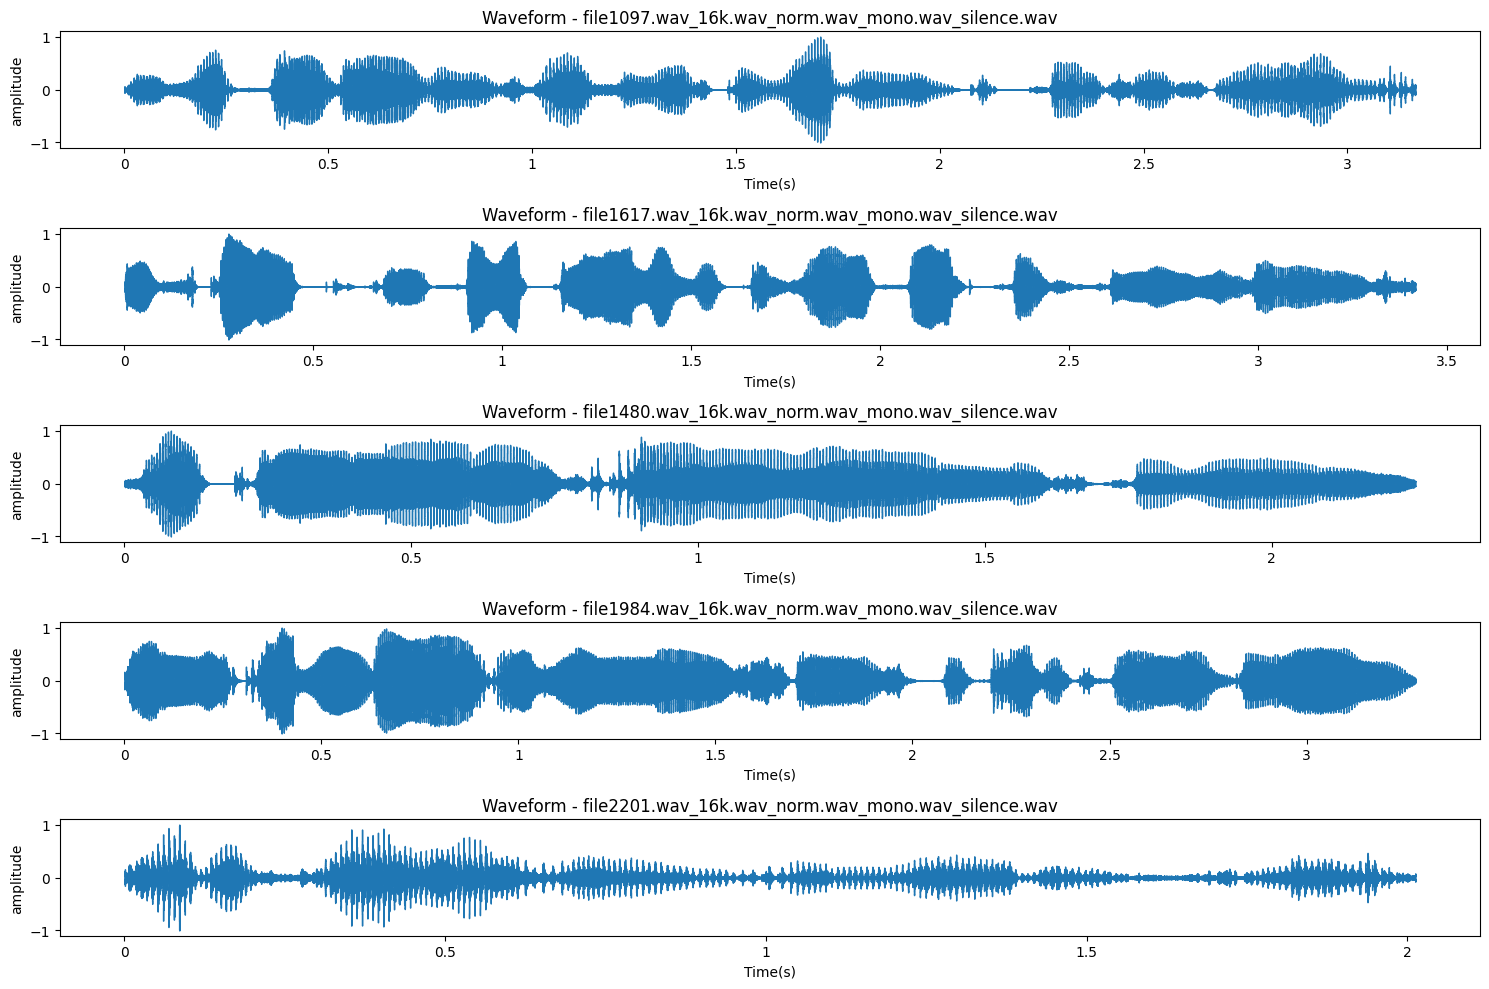

In [3]:
import matplotlib.pyplot as plt
import random
import librosa.display as ld

random_files = random.sample(audio_files, 5)


plt.figure(figsize=(15,10))

for i,file in enumerate(random_files):
    y,sr = librosa.load(file, sr=None)
    plt.subplot(5,1,i+1)
    ld.waveshow(y, sr=sr)
    plt.title(f'Waveform - {os.path.basename(file)}')
    plt.xlabel("Time(s)")
    plt.ylabel("amplitude")

plt.tight_layout()
plt.show()

    

fungsi Preprocessing audio

In [4]:
import numpy as np
def preprocess_audio(file_path, sr=16000,n_mels=128, target_length=350 ):
    try :    
        y,sr = librosa.load(file_path,sr=sr)
        if len(y) == 0:
            return np.zeros((n_mels, target_length), dtype=np.float32)
    except Exception as e:
        print(f"error load {file_path} : {e}")
        return np.zeros((n_mels, target_length), dtype=np.float32)
        
    mel=librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=160, n_mels=n_mels)

    log_mel= librosa.power_to_db(mel, ref=np.max)

    # Seragamkan

    if log_mel.shape[1] <target_length:
        # padding
        pad_width = target_length - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0,0), (0,pad_width)), mode='constant')
    else :
        log_mel= log_mel[:, :target_length]

    return log_mel


    

In [5]:
audio_mal = [preprocess_audio(f) for f in audio_files]

In [6]:
audio_mal[0]

array([[-40.86886 , -39.364418, -39.10898 , ...,   0.      ,   0.      ,
          0.      ],
       [-41.607536, -40.873474, -40.696827, ...,   0.      ,   0.      ,
          0.      ],
       [-48.530792, -50.057144, -51.323166, ...,   0.      ,   0.      ,
          0.      ],
       ...,
       [-64.075874, -65.363594, -69.818275, ...,   0.      ,   0.      ,
          0.      ],
       [-64.458664, -66.61197 , -74.40248 , ...,   0.      ,   0.      ,
          0.      ],
       [-64.79784 , -66.99845 , -75.0294  , ...,   0.      ,   0.      ,
          0.      ]], dtype=float32)

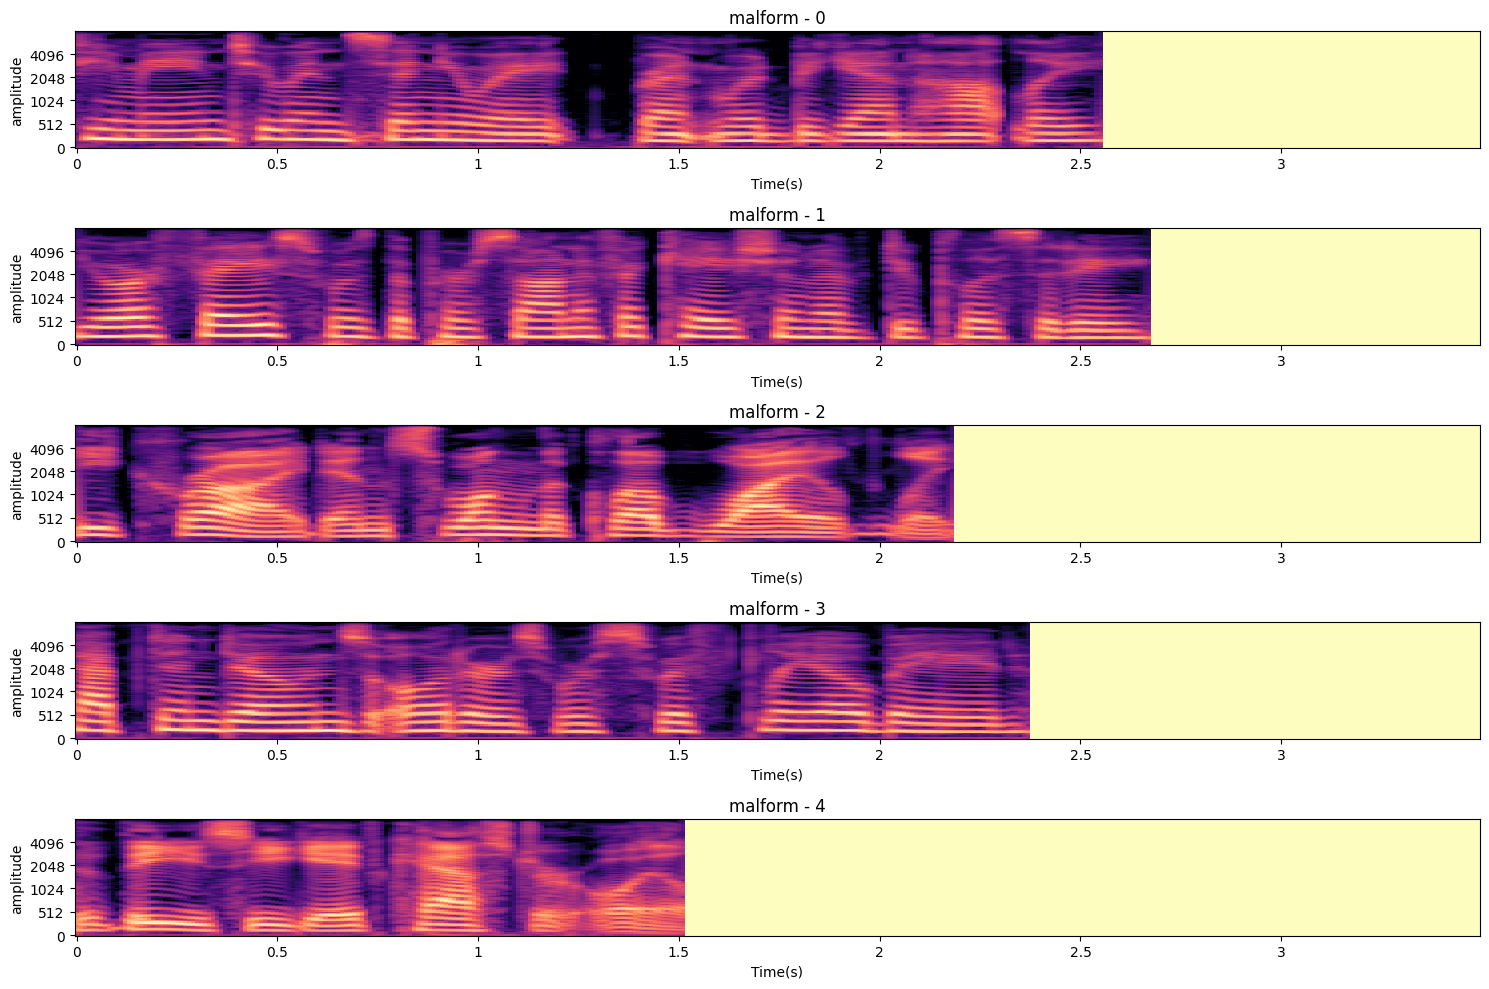

In [7]:
import matplotlib.pyplot as plt
import random
import librosa.display as ld

random_files_mal = random.sample(audio_mal, 5)


plt.figure(figsize=(15,10))

for i,file in enumerate(random_files_mal):
    plt.subplot(5,1,i+1)
    ld.specshow(file, x_axis="time", y_axis="mel", sr=16000, hop_length=160)
    plt.title(f'malform - {i}')
    plt.xlabel("Time(s)")
    plt.ylabel("amplitude")

plt.tight_layout()
plt.show()

    

In [8]:
def load_dataset(base_dir, sr=16000, n_mels=128, target_length=350):
    data= {}

    for split in os.listdir(base_dir):
        split_path = os.path.join(base_dir, split)
        X,y=[], []

        for label in os.listdir(split_path):
            label_path=os.path.join(split_path, label)

            audio_files = glob.glob(os.path.join(label_path, "*wav"))

            for file in audio_files:
                log_mel = preprocess_audio(file, sr=sr, n_mels=n_mels, target_length=target_length)
                X.append(log_mel)
                y.append(label)

        data[split]= (np.array(X), np.array(y))

    return data



In [9]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio

# ==== Dataset ====
class AudioDataset(Dataset):
    def __init__(self, base_dir, split="train", sr=16000, n_mels=128, target_length=350):
        self.files = []
        self.labels = []
        self.label2idx = {}

        # label folder
        split_path = os.path.join(base_dir, split)
        label_names = sorted(os.listdir(split_path))
        self.label2idx = {label: i for i, label in enumerate(label_names)}

        for label in label_names:
            label_path = os.path.join(split_path, label)
            for f in os.listdir(label_path):
                if f.endswith(".wav"):
                    self.files.append(os.path.join(label_path, f))
                    self.labels.append(self.label2idx[label])

        # transforms (GPU friendly)
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr,
            n_fft=1024,
            hop_length=512,
            n_mels=n_mels
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

        self.target_length = target_length
        self.n_mels = n_mels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]

        try:
            waveform, sr = torchaudio.load(file_path)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            # Return zero tensor & label 0, atau bisa panggil self.__getitem__(idx+1) untuk skip
            waveform = torch.zeros(1, 16000)
            sr = 16000

        if sr != 16000:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
            waveform = resampler(waveform)

        mel = self.mel_transform(waveform)
        mel = self.db_transform(mel)
        mel = mel.squeeze(0).transpose(0, 1)

        if mel.shape[0] < self.target_length:
            pad_amt = self.target_length - mel.shape[0]
            mel = torch.cat([mel, torch.zeros(pad_amt, self.n_mels)], dim=0)
        else:
            mel = mel[:self.target_length, :]

        return mel, label



# ==== Pakai Dataset + DataLoader ====   # dataset/train/label/audio.wav
batch_size = 16
target_length = 350   # sesuai AST

train_dataset = AudioDataset(base_dir, split="training", target_length=target_length)
val_dataset   = AudioDataset(base_dir, split="validation", target_length=target_length)
test_dataset   = AudioDataset(base_dir, split="testing", target_length=target_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader   = DataLoader(test_dataset, batch_size=batch_size)

# ==== Test ====
mel, label = next(iter(train_loader))
print("Mel shape:", mel.shape)    # (B, T, 128)
print("Label shape:", label.shape)


Mel shape: torch.Size([16, 350, 128])
Label shape: torch.Size([16])


In [10]:
!pip uninstall timm -y
!pip install timm==0.4.5


Found existing installation: timm 0.4.5
Uninstalling timm-0.4.5:
  Successfully uninstalled timm-0.4.5
  Using cached timm-0.4.5-py3-none-any.whl.metadata (24 kB)
Using cached timm-0.4.5-py3-none-any.whl (287 kB)


In [11]:
import torch
import torch.nn as nn
from torch.cuda.amp import autocast
import os
import timm
from timm.models.layers import to_2tuple,trunc_normal_
from torch import amp

# override the timm package to relax the input shape constraint.
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()

        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        num_patches = (img_size[1] // patch_size[1]) * (img_size[0] // patch_size[0])
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = num_patches

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class ASTModel(nn.Module):
    """
    The AST model.
    :param label_dim: the label dimension, i.e., the number of total classes, it is 527 for AudioSet, 50 for ESC-50, and 35 for speechcommands v2-35
    :param fstride: the stride of patch spliting on the frequency dimension, for 16*16 patchs, fstride=16 means no overlap, fstride=10 means overlap of 6
    :param tstride: the stride of patch spliting on the time dimension, for 16*16 patchs, tstride=16 means no overlap, tstride=10 means overlap of 6
    :param input_fdim: the number of frequency bins of the input spectrogram
    :param input_tdim: the number of time frames of the input spectrogram
    :param imagenet_pretrain: if use ImageNet pretrained model
    :param audioset_pretrain: if use full AudioSet and ImageNet pretrained model
    :param model_size: the model size of AST, should be in [tiny224, small224, base224, base384], base224 and base 384 are same model, but are trained differently during ImageNet pretraining.
    """
    def __init__(self, label_dim=527, fstride=10, tstride=10, input_fdim=128, input_tdim=1024, imagenet_pretrain=True, audioset_pretrain=False, model_size='base384', verbose=True):

        super(ASTModel, self).__init__()
        assert timm.__version__ == '0.4.5', 'Please use timm == 0.4.5, the code might not be compatible with newer versions.'

        if verbose == True:
            print('---------------AST Model Summary---------------')
            print('ImageNet pretraining: {:s}, AudioSet pretraining: {:s}'.format(str(imagenet_pretrain),str(audioset_pretrain)))
        # override timm input shape restriction
        timm.models.vision_transformer.PatchEmbed = PatchEmbed

        # if AudioSet pretraining is not used (but ImageNet pretraining may still apply)
        if audioset_pretrain == False:
            if model_size == 'tiny224':
                self.v = timm.create_model('vit_deit_tiny_distilled_patch16_224', pretrained=imagenet_pretrain)
            elif model_size == 'small224':
                self.v = timm.create_model('vit_deit_small_distilled_patch16_224', pretrained=imagenet_pretrain)
            elif model_size == 'base224':
                self.v = timm.create_model('vit_deit_base_distilled_patch16_224', pretrained=imagenet_pretrain)
            elif model_size == 'base384':
                self.v = timm.create_model('vit_deit_base_distilled_patch16_384', pretrained=imagenet_pretrain)
            else:
                raise Exception('Model size must be one of tiny224, small224, base224, base384.')
            self.original_num_patches = self.v.patch_embed.num_patches
            self.oringal_hw = int(self.original_num_patches ** 0.5)
            self.original_embedding_dim = self.v.pos_embed.shape[2]
            self.mlp_head = nn.Sequential(nn.LayerNorm(self.original_embedding_dim), nn.Linear(self.original_embedding_dim, label_dim))

            # automatcially get the intermediate shape
            f_dim, t_dim = self.get_shape(fstride, tstride, input_fdim, input_tdim)
            num_patches = f_dim * t_dim
            self.v.patch_embed.num_patches = num_patches
            if verbose == True:
                print('frequncey stride={:d}, time stride={:d}'.format(fstride, tstride))
                print('number of patches={:d}'.format(num_patches))

            # the linear projection layer
            new_proj = torch.nn.Conv2d(1, self.original_embedding_dim, kernel_size=(16, 16), stride=(fstride, tstride))
            if imagenet_pretrain == True:
                new_proj.weight = torch.nn.Parameter(torch.sum(self.v.patch_embed.proj.weight, dim=1).unsqueeze(1))
                new_proj.bias = self.v.patch_embed.proj.bias
            self.v.patch_embed.proj = new_proj

            # the positional embedding
            if imagenet_pretrain == True:
                # get the positional embedding from deit model, skip the first two tokens (cls token and distillation token), reshape it to original 2D shape (24*24).
                new_pos_embed = self.v.pos_embed[:, 2:, :].detach().reshape(1, self.original_num_patches, self.original_embedding_dim).transpose(1, 2).reshape(1, self.original_embedding_dim, self.oringal_hw, self.oringal_hw)
                # cut (from middle) or interpolate the second dimension of the positional embedding
                if t_dim <= self.oringal_hw:
                    new_pos_embed = new_pos_embed[:, :, :, int(self.oringal_hw / 2) - int(t_dim / 2): int(self.oringal_hw / 2) - int(t_dim / 2) + t_dim]
                else:
                    new_pos_embed = torch.nn.functional.interpolate(new_pos_embed, size=(self.oringal_hw, t_dim), mode='bilinear')
                # cut (from middle) or interpolate the first dimension of the positional embedding
                if f_dim <= self.oringal_hw:
                    new_pos_embed = new_pos_embed[:, :, int(self.oringal_hw / 2) - int(f_dim / 2): int(self.oringal_hw / 2) - int(f_dim / 2) + f_dim, :]
                else:
                    new_pos_embed = torch.nn.functional.interpolate(new_pos_embed, size=(f_dim, t_dim), mode='bilinear')
                # flatten the positional embedding
                new_pos_embed = new_pos_embed.reshape(1, self.original_embedding_dim, num_patches).transpose(1,2)
                # concatenate the above positional embedding with the cls token and distillation token of the deit model.
                self.v.pos_embed = nn.Parameter(torch.cat([self.v.pos_embed[:, :2, :].detach(), new_pos_embed], dim=1))
            else:
                # if not use imagenet pretrained model, just randomly initialize a learnable positional embedding
                # TODO can use sinusoidal positional embedding instead
                new_pos_embed = nn.Parameter(torch.zeros(1, self.v.patch_embed.num_patches + 2, self.original_embedding_dim))
                self.v.pos_embed = new_pos_embed
                trunc_normal_(self.v.pos_embed, std=.02)

        # now load a model that is pretrained on both ImageNet and AudioSet
        elif audioset_pretrain == True:
            if audioset_pretrain == True and imagenet_pretrain == False:
                raise ValueError('currently model pretrained on only audioset is not supported, please set imagenet_pretrain = True to use audioset pretrained model.')
            if model_size != 'base384':
                raise ValueError('currently only has base384 AudioSet pretrained model.')
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            if os.path.exists('../../pretrained_models/audioset_10_10_0.4593.pth') == False:
                # this model performs 0.4593 mAP on the audioset eval set
                audioset_mdl_url = 'https://www.dropbox.com/s/cv4knew8mvbrnvq/audioset_0.4593.pth?dl=1'
                wget.download(audioset_mdl_url, out='../../pretrained_models/audioset_10_10_0.4593.pth')
            sd = torch.load('../../pretrained_models/audioset_10_10_0.4593.pth', map_location=device)
            audio_model = ASTModel(label_dim=527, fstride=10, tstride=10, input_fdim=128, input_tdim=1024, imagenet_pretrain=False, audioset_pretrain=False, model_size='base384', verbose=False)
            audio_model = torch.nn.DataParallel(audio_model)
            audio_model.load_state_dict(sd, strict=False)
            self.v = audio_model.module.v
            self.original_embedding_dim = self.v.pos_embed.shape[2]
            self.mlp_head = nn.Sequential(nn.LayerNorm(self.original_embedding_dim), nn.Linear(self.original_embedding_dim, label_dim))

            f_dim, t_dim = self.get_shape(fstride, tstride, input_fdim, input_tdim)
            num_patches = f_dim * t_dim
            self.v.patch_embed.num_patches = num_patches
            if verbose == True:
                print('frequncey stride={:d}, time stride={:d}'.format(fstride, tstride))
                print('number of patches={:d}'.format(num_patches))

            new_pos_embed = self.v.pos_embed[:, 2:, :].detach().reshape(1, 1212, 768).transpose(1, 2).reshape(1, 768, 12, 101)
            # if the input sequence length is larger than the original audioset (10s), then cut the positional embedding
            if t_dim < 101:
                new_pos_embed = new_pos_embed[:, :, :, 50 - int(t_dim/2): 50 - int(t_dim/2) + t_dim]
            # otherwise interpolate
            else:
                new_pos_embed = torch.nn.functional.interpolate(new_pos_embed, size=(12, t_dim), mode='bilinear')
            if f_dim < 12:
                new_pos_embed = new_pos_embed[:, :, 6 - int(f_dim/2): 6 - int(f_dim/2) + f_dim, :]
            # otherwise interpolate
            elif f_dim > 12:
                new_pos_embed = torch.nn.functional.interpolate(new_pos_embed, size=(f_dim, t_dim), mode='bilinear')
            new_pos_embed = new_pos_embed.reshape(1, 768, num_patches).transpose(1, 2)
            self.v.pos_embed = nn.Parameter(torch.cat([self.v.pos_embed[:, :2, :].detach(), new_pos_embed], dim=1))

    def get_shape(self, fstride, tstride, input_fdim=128, input_tdim=1024):
        test_input = torch.randn(1, 1, input_fdim, input_tdim)
        test_proj = nn.Conv2d(1, self.original_embedding_dim, kernel_size=(16, 16), stride=(fstride, tstride))
        test_out = test_proj(test_input)
        f_dim = test_out.shape[2]
        t_dim = test_out.shape[3]
        return f_dim, t_dim

    @amp.autocast(device_type='cuda')
    def forward(self, x):
        """
        :param x: the input spectrogram, expected shape: (batch_size, time_frame_num, frequency_bins), e.g., (12, 1024, 128)
        :return: prediction
        """
        # expect input x = (batch_size, time_frame_num, frequency_bins), e.g., (12, 1024, 128)
        x = x.unsqueeze(1)
        x = x.transpose(2, 3)

        B = x.shape[0]
        x = self.v.patch_embed(x)
        cls_tokens = self.v.cls_token.expand(B, -1, -1)
        dist_token = self.v.dist_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, dist_token, x), dim=1)
        x = x + self.v.pos_embed
        x = self.v.pos_drop(x)
        for blk in self.v.blocks:
            x = blk(x)
        x = self.v.norm(x)
        x = (x[:, 0] + x[:, 1]) / 2

        x = self.mlp_head(x)
        return x

print('berhasil')

berhasil


In [12]:
# -*- coding: utf-8 -*-
import torch
import torch.nn as nn
import torch.optim as optim

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==== Model ====
n_classes = len(train_dataset.label2idx)
input_tdim = target_length

model = ASTModel(
    label_dim=n_classes,
    input_fdim=128,
    input_tdim=input_tdim,
    fstride=10,
    tstride=10,
    imagenet_pretrain=True,
    audioset_pretrain=False
)
model = model.to(device)

# ==== Loss & Optimizer ====
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# ==== Training & Eval Functions ====
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for mel, label in loader:
        mel, label = mel.to(device), label.to(device)
        optimizer.zero_grad()
        outputs = model(mel)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * mel.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(label).sum().item()
        total += label.size(0)
    return total_loss / total, correct / total

def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for mel, label in loader:
            mel, label = mel.to(device), label.to(device)
            outputs = model(mel)
            loss = criterion(outputs, label)
            total_loss += loss.item() * mel.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(label).sum().item()
            total += label.size(0)
    return total_loss / total, correct / total

# ==== Training Loop ====
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_model(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")


---------------AST Model Summary---------------
ImageNet pretraining: True, AudioSet pretraining: False
frequncey stride=10, time stride=10
number of patches=408
Error loading /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real/file15440.wav_16k.wav_norm.wav_mono.wav_silence.wav: Failed to decode audio.
Error loading /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real/file11064.wav_16k.wav_norm.wav_mono.wav_silence.wav: Failed to decode audio.
Epoch 1/10 | Train Loss: 0.0425 Acc: 0.9844 | Val Loss: 0.0107 Acc: 0.9969
Error loading /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real/file15440.wav_16k.wav_norm.wav_mono.wav_silence.wav: Failed to decode audio.
Error loading /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real/file11064.wav_16k.wav_norm.wav_mono.wav_silence.wav: Failed to decode audio.
Epoch 2/10 | Train Loss: 0.0139 Acc: 0.9953 | Val Loss: 0.0177 Acc: 0.9951
Error loading /kaggle/input/the-fake-or-

In [13]:
print(timm.__version__)

0.4.5


In [25]:
from sklearn.metrics import classification_report, precision_score, f1_score, accuracy_score, recall_score

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for mel, label in test_loader:
        mel, label = mel.to(device), label.to(device)
        outputs = model(mel)  # perbaikan typo
        preds = outputs.argmax(dim=1)

        all_labels.extend(label.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Precision, Recall, F1-score
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")
accuracy = accuracy_score(all_labels, all_preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0     0.9942    0.3633    0.5321      2370
           1     0.5995    0.9978    0.7490      2264

    accuracy                         0.6733      4634
   macro avg     0.7969    0.6805    0.6406      4634
weighted avg     0.8014    0.6733    0.6381      4634

Accuracy: 0.6733
Precision (macro): 0.7969
Recall (macro): 0.6805
F1-score (macro): 0.6406


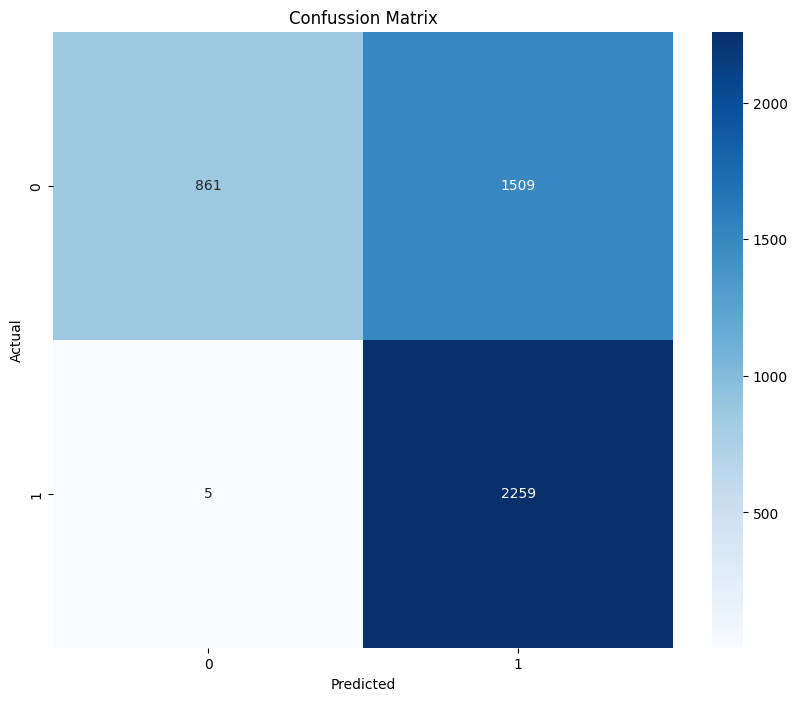

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm=confusion_matrix(all_labels,all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confussion Matrix')

plt.show()

In [22]:
torch.save(model.state_dict(), "ast_model_state.pth")

In [24]:
mel, label = next(iter(test_loader))
print("Mel shape:", mel.shape)    # (B, T, 128)
print("Label shape:", label.shape)

Mel shape: torch.Size([16, 350, 128])
Label shape: torch.Size([16])
